In [1]:
import numpy as np
import matplotlib.pyplot as plt
from my_functions import build_poly_features, logregression_GD, plot_logregression_regions

## Example 1

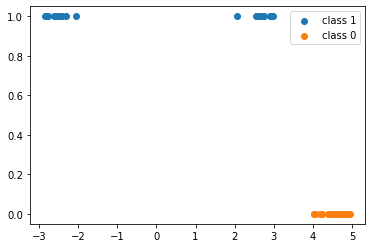

In [2]:
x = np.zeros(40)
y = np.zeros(40)

x[0:10] = -3+ np.random.rand(10)
y[0:10] = 1

x[10:20] = 2 + np.random.rand(10)
y[10:20] = 1

x[20:40] = 4 + np.random.rand(20)
y[20:40] = 0

plt.scatter(x[y==1],y[y==1], label = 'class 1')
plt.scatter(x[y==0],y[y==0], label = 'class 0')
plt.legend()

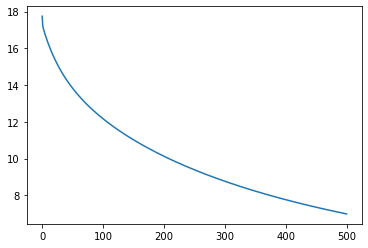

In [3]:
X = build_poly_features(x,degree=1)

theta, cost = logregression_GD(X,y,learning_rate = 0.01, epochs = 500)

plt.plot(cost)

In [4]:
def sigmoid(t):
    return 1/(1+np.exp(-t))

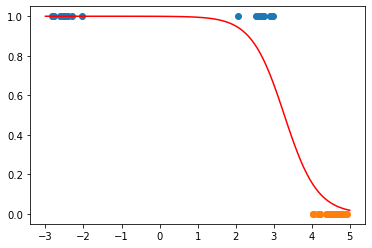

In [5]:
plt.scatter(x[y==1],y[y==1], label = 'class 1')
plt.scatter(x[y==0],y[y==0], label = 'class 0')

x_plot = np.linspace(-3,5,100)
X_plot = build_poly_features(x_plot,degree=1)
y_plot = sigmoid(X_plot.dot(theta))

plt.plot(x_plot,y_plot,color='red')

## Example 2

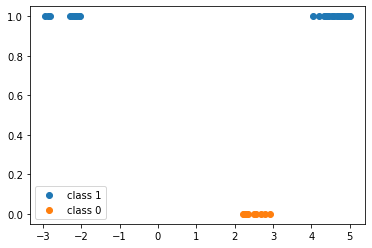

In [6]:
x = np.zeros(40)
y = np.zeros(40)

x[0:10] = -3+ np.random.rand(10)
y[0:10] = 1

x[10:20] = 2 + np.random.rand(10)
y[10:20] = 0

x[20:40] = 4 + np.random.rand(20)
y[20:40] = 1

plt.scatter(x[y==1],y[y==1], label = 'class 1')
plt.scatter(x[y==0],y[y==0], label = 'class 0')
plt.legend()

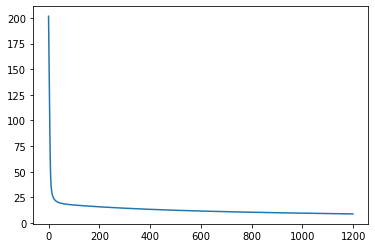

In [7]:
X = build_poly_features(x,degree=2)

theta, cost = logregression_GD(X,y,learning_rate = 0.0001, epochs = 1200)

plt.plot(cost)

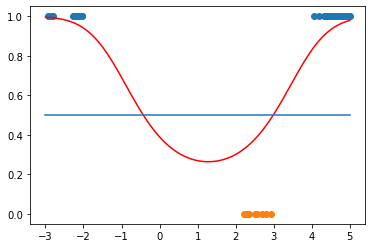

In [8]:
plt.scatter(x[y==1],y[y==1], label = 'class 1')
plt.scatter(x[y==0],y[y==0], label = 'class 0')

x_plot = np.linspace(-3,5,100)
X_plot = build_poly_features(x_plot,degree=2)
y_plot = sigmoid(X_plot.dot(theta))

plt.plot(x_plot,y_plot,color='red')
plt.plot(x_plot,0.5*np.ones(100))

## Example 3: More D

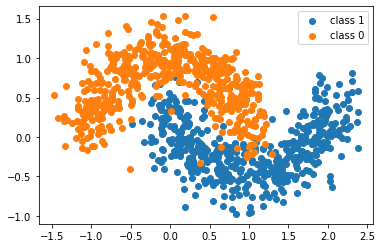

In [9]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples = 1000, noise = 0.2 )
plt.scatter(X[y==1,0],X[y==1,1],label = 'class 1')
plt.scatter(X[y==0,0],X[y==0,1],label = 'class 0')
plt.legend()

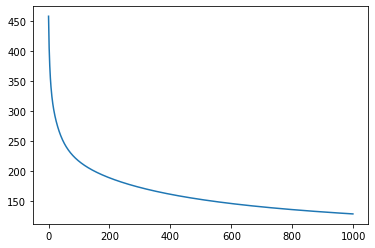

In [15]:
# use new function that builds a grid of points, and evalute the log regression model
# at the grid points

X_poly = build_poly_features(X,degree=3)
theta,cost = logregression_GD(X_poly,y,learning_rate=0.001,epochs=1000)
plt.plot(cost)

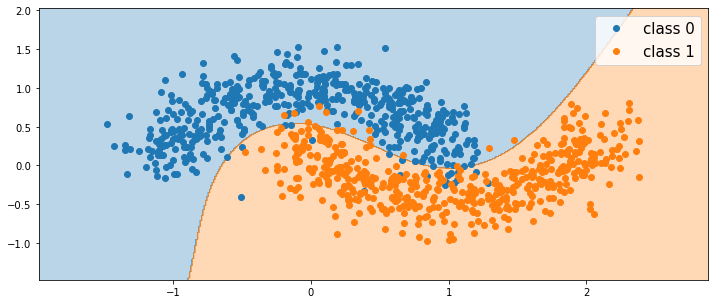

In [16]:
plot_logregression_regions(X,y,theta,degree=3)

## Example 4

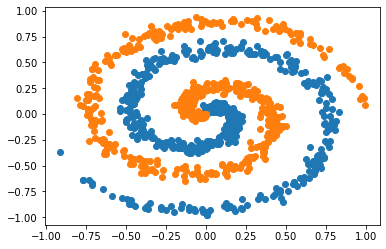

In [17]:
classes = 2
n_points = 500
noise = 0.35
radius = 10

X = np.zeros((n_points*classes, 2))
y = np.zeros(n_points*classes).astype('int')

for class_number in range(classes):
    ix = range(n_points*class_number, n_points*(class_number+1))
    r = np.linspace(0,1, n_points)
    t = np.linspace(class_number*radius, (class_number+1)*radius, n_points) + np.random.randn(n_points)*noise
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = class_number
    
plt.plot(X[y==0,0],X[y==0,1],'o',label = 'class '+str(0))
plt.plot(X[y==1,0],X[y==1,1],'o',label = 'class '+str(1))

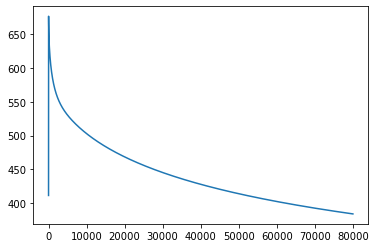

In [24]:
X_poly = build_poly_features(X,degree=12)
theta,cost = logregression_GD(X_poly,y,learning_rate=0.001,epochs=80000)
plt.plot(cost)

/Users/vanmagnan/Documents/M 562/my_functions.py:120: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-t))


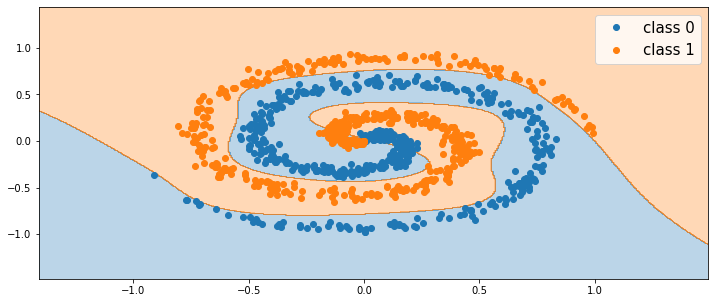

In [25]:
plot_logregression_regions(X,y,theta,degree=12)